In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA



# 1. Data Preparation

In [10]:
# Load dataset
df = pd.read_csv("F:\masai_notes\Assignmnt_4a_4b_ML\data\q2_customers.csv")
print(df.head())                              #--------> Display first few rows
print("-" * 50)
print(df.info())                                #------->To check for non-numeric columns 
print("-" * 50)
numeric_df = df.select_dtypes(include=['int64', 'float64'])     #-------> Select only numeric columns for scaling   
print(numeric_df.head())



   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    i

In [12]:
# Apply StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)
print(scaled_data)  # Display first 5 rows of scaled data

[[-0.72521859 -0.17615043  0.11016555 -0.26501121 -0.0899507   0.55095233]
 [-1.48846049 -1.04682639  0.48615719 -0.9804657  -0.83517593 -0.68068477]
 [ 0.17679458  0.2673371  -0.45382191 -0.23685064 -0.67404615 -0.27013907]
 ...
 [ 0.24618021  0.1432203   0.11016555 -0.78158167 -0.79489349 -0.68068477]
 [-0.30890482 -0.23321247  0.11016555 -0.27997151 -0.04966825  0.55095233]
 [-1.41907487 -1.2411359   1.23814046 -0.79962203 -0.67404615 -1.50177617]]


# 

K-Means clustering works by calculating distances between data points. If features are not scaled, variables with larger values will dominate the distance calculation.

For example, if one feature ranges from 0–1000 and another from 0–10, the larger feature will have more influence, even if it is not more important.

StandardScaler transforms the data so that each feature has:
 Mean = 0
 Standard deviation = 1

This ensures that all features contribute equally to the clustering process, leading to more accurate and meaningful clusters.

# Choosing K — Elbow Method

In [14]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

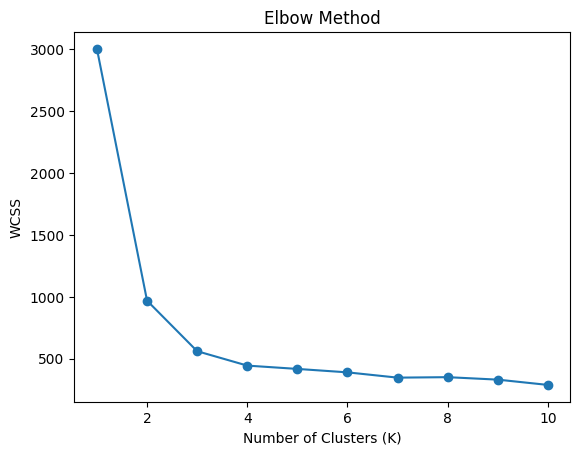

In [15]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

###

The Elbow Method is used to determine the optimal number of clusters in K-Means clustering by computing the Within-Cluster Sum of Squares (WCSS) for different values of K.

From the plotted graph, WCSS decreases sharply from K = 1 to K = 4, indicating significant improvement in cluster compactness. After K = 4, the rate of decrease slows down and the curve begins to flatten.

This point, where the curve changes direction, is known as the "elbow point".

Therefore, the optimal number of clusters is K = 4, as increasing K beyond this value does not result in substantial improvement.

# 3. K-Means Clustering

In [16]:
# Final K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_data) 
# View cluster centroids (in original scale)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_original, columns=numeric_df.columns)
centroid_df.index = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']
print(centroid_df)


                 age  annual_spend  visits_per_month  basket_size  \
Cluster 0  24.676471  14847.370588         14.341176   558.970588   
Cluster 1  57.134146  89778.451220          2.463415  5345.500000   
Cluster 2  40.387879  43340.733333          8.193939  2021.684848   
Cluster 3  56.409639  89052.614458          2.590361  5713.361446   

           days_since_last_visit  num_categories_purchased  
Cluster 0               9.076471                  2.111765  
Cluster 1             147.060976                  7.524390  
Cluster 2              35.187879                  4.424242  
Cluster 3              64.156627                  7.506024  


### Cluster Interpretation

After applying K-Means clustering with K = 4, the customers are divided into four distinct groups based on their behavior:

- Cluster 0 (Young Low-Spenders) : 
  These customers are young (around 24 years old) with low annual spending and small basket sizes. They visit frequently but spend less per purchase. They are regular but low-value customers.

- Cluster 1 (High-Spending Occasional Customers) : 
  These customers are around 57 years old with very high annual spending and large basket sizes. However, they visit less frequently and have long gaps between visits. They are high-value but less frequent customers.

- Cluster 2 (Active Moderate Spenders) : 
  These customers are middle-aged (around 40 years old) with moderate to high spending. They visit regularly and have balanced purchasing behavior. They represent stable and consistent customers.

- Cluster 3 (Premium but Infrequent Buyers) : 
  These customers are older (around 56 years old) with high spending and large basket sizes, but they visit very rarely. They are premium customers but not very active.

# 4. Dimensionality Reduction with PCA

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 variance explained: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

PC1 variance explained: 83.56%
PC2 variance explained: 5.57%
Total variance explained: 89.13%


In [ ]:
# View how original features contribute to each PC

loadings = pd.DataFrame(pca.components_,columns=numeric_df.columns, index=['PC1', 'PC2'])

print(loadings)

          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


### PCA Interpretation

PCA is applied to reduce the dataset into two principal components while retaining most of the important information.

The explained variance ratio shows that PC1 captures the majority of the variance, while PC2 captures the remaining part.

From the feature loadings:

- PC1 (Principal Component 1) is strongly influenced by features such as annual spending, basket size, number of categories purchased, and age, while visits per month has a negative contribution. This indicates that PC1 represents overall customer value and spending behavior. Customers with high PC1 scores are high spenders who purchase larger baskets but visit less frequently.

- PC2 (Principal Component 2) is mainly influenced by days since last visit, with a very strong contribution, along with some influence from visits per month. This suggests that PC2 represents customer activity or recency. Customers with high PC2 values have not visited recently, while lower values indicate more active customers.

Overall, PCA reduces the dataset into two key dimensions: customer value (PC1) and customer activity (PC2).

# 5. Cluster Visualisation

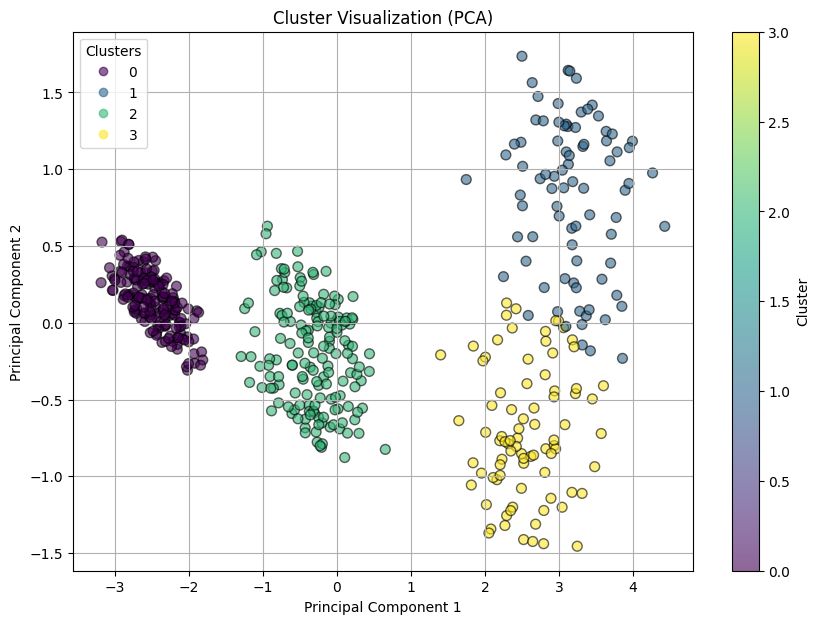

In [25]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
 c=df['Cluster'], cmap='viridis',
 alpha=0.6, edgecolors='k', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Cluster Visualization (PCA)')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()
